# Snow Pole Detection - EDA & Data Preparation

Exploratory Data Analysis for Poles2025 dataset

**Important Notes:**
- Dataset is **read-only**
- Labels are in standard YOLO **.txt** format
- All outputs are saved to local `eda_outputs/` directory

In [2]:
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from collections import defaultdict
import pandas as pd
from tqdm import tqdm
import json

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded")

Libraries loaded


## 1. Dataset Configuration

Dataset is **read-only**. Labels are in standard YOLO **.txt** format.

In [3]:
# ============================================================
# CONFIGURATION - Adjust paths as needed
# ============================================================

# Dataset path (READ-ONLY)
# For Cybele lab:
BASE_PATH = Path("/datasets/tdt4265/Poles2025")
# For IDUN cluster, uncomment:
# BASE_PATH = Path("/cluster/projects/vc/courses/TDT17/ad/Poles2025")

# Dataset structures - labels are .txt files (standard YOLO format)
DATASETS = {
    'Road_poles_iPhone': {
        'path': BASE_PATH / 'Road_poles_iPhone',
        'structure': 'type1',
        'splits': {
            'Train': {'images': 'images/Train/train', 'labels': 'labels/Train/train'},
            'Validation': {'images': 'images/Validation/val', 'labels': 'labels/Validation/val'},
            'Test': {'images': 'images/Test/test', 'labels': None}
        }
    },
    'roadpoles_v1': {
        'path': BASE_PATH / 'roadpoles_v1',
        'structure': 'type2',
        'splits': {
            'train': {'images': 'train/images', 'labels': 'train/labels'},
            'valid': {'images': 'valid/images', 'labels': 'valid/labels'},
            'test': {'images': 'test/images', 'labels': None}
        }
    }
}

# Output directory (local, writable)
OUTPUT_DIR = Path('eda_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Dataset path: {BASE_PATH}")
print(f"Dataset exists: {BASE_PATH.exists()}")
print(f"Output directory: {OUTPUT_DIR}")

Dataset path: /datasets/tdt4265/Poles2025
Dataset exists: True
Output directory: eda_outputs


## 2. Helper Functions: Read YOLO Labels

In [4]:
def read_yolo_label(txt_path):
    """
    Read YOLO format labels from a .txt file.
    Returns list of lines.
    """
    try:
        with open(txt_path, 'r') as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
        return lines
    except Exception as e:
        print(f"Error reading {txt_path}: {e}")
        return []


def parse_yolo_line(line):
    """
    Parse a YOLO format line: class_id x_center y_center width height
    Returns dict or None if invalid.
    """
    parts = line.strip().split()
    if len(parts) >= 5:
        try:
            return {
                'class': int(parts[0]),
                'x_center': float(parts[1]),
                'y_center': float(parts[2]),
                'width': float(parts[3]),
                'height': float(parts[4])
            }
        except ValueError:
            return None
    return None


# Test reading a txt label
print("Testing label reading...")
test_labels_path = BASE_PATH / 'roadpoles_v1' / 'train' / 'labels'
if test_labels_path.exists():
    txt_files = list(test_labels_path.glob('*.txt'))[:1]
    if txt_files:
        sample_lines = read_yolo_label(txt_files[0])
        print(f"Sample label file: {txt_files[0].name}")
        print(f"Content: {sample_lines}")
        if sample_lines:
            parsed = parse_yolo_line(sample_lines[0])
            print(f"Parsed: {parsed}")
    else:
        print("No .txt files found in test path")
else:
    print(f"Test path not found: {test_labels_path}")

Testing label reading...
Sample label file: frame_001755.txt
Content: ['0 0.612216 0.597790 0.005099 0.100877']
Parsed: {'class': 0, 'x_center': 0.612216, 'y_center': 0.59779, 'width': 0.005099, 'height': 0.100877}


## 3. Dataset Structure Analysis

In [5]:
def analyze_dataset(dataset_name, dataset_info):
    """Analyze dataset structure - labels are .txt files."""
    print(f"\n{'='*80}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*80}")
    
    dataset_path = dataset_info['path']
    
    if not dataset_path.exists():
        print(f"Dataset not found at: {dataset_path}")
        return None
    
    stats = {
        'name': dataset_name,
        'path': str(dataset_path),
        'splits': {}
    }
    
    for split_name, paths in dataset_info['splits'].items():
        images_path = dataset_path / paths['images']
        labels_path = dataset_path / paths['labels'] if paths['labels'] else None
        
        print(f"\n{split_name}:")
        
        if not images_path.exists():
            print(f"  Images path not found: {images_path}")
            continue
        
        # Get image files
        image_files = list(images_path.glob('*.jpg')) + list(images_path.glob('*.JPG')) + \
                     list(images_path.glob('*.png')) + list(images_path.glob('*.PNG'))
        num_images = len(image_files)
        
        # Get label files (.txt format)
        num_labels = 0
        label_files = []
        if labels_path and labels_path.exists():
            label_files = list(labels_path.glob('*.txt'))
            num_labels = len(label_files)
        elif labels_path:
            print(f"  Labels path not found: {labels_path}")
        
        if num_images > 0:
            stats['splits'][split_name] = {
                'images': num_images,
                'labels': num_labels,
                'images_path': images_path,
                'labels_path': labels_path,
                'image_files': image_files,
                'label_files': label_files
            }
            
            print(f"  Images: {num_images} ✓")
            if paths['labels']:
                print(f"  Labels: {num_labels} {'✓' if num_labels > 0 else '✗'}")
            else:
                print(f"  Labels: N/A (test set)")
    
    stats['total_images'] = sum(s['images'] for s in stats['splits'].values())
    stats['total_labels'] = sum(s['labels'] for s in stats['splits'].values())
    
    print(f"\n{'='*40}")
    print(f"Total: {stats['total_images']} images, {stats['total_labels']} labels")
    print(f"{'='*40}")
    
    return stats

# Analyze all datasets
all_stats = {}
for name, info in DATASETS.items():
    result = analyze_dataset(name, info)
    if result:
        all_stats[name] = result


Dataset: Road_poles_iPhone

Train:
  Images: 942 ✓
  Labels: 942 ✓

Validation:
  Images: 261 ✓
  Labels: 261 ✓

Test:
  Images: 138 ✓
  Labels: N/A (test set)

Total: 1341 images, 1203 labels

Dataset: roadpoles_v1

train:
  Images: 322 ✓
  Labels: 322 ✓

valid:
  Images: 92 ✓
  Labels: 92 ✓

test:
  Images: 46 ✓
  Labels: N/A (test set)

Total: 460 images, 414 labels


## 4. Check Label Coverage

In [6]:
def check_label_coverage(stats_dict):
    """Check which images have corresponding .txt labels."""
    print(f"\n{'='*80}")
    print("Label Coverage Analysis")
    print(f"{'='*80}")
    
    coverage_stats = {}
    
    for dataset_name, stats in stats_dict.items():
        print(f"\n{dataset_name}:")
        coverage_stats[dataset_name] = {}
        
        for split_name, split_data in stats['splits'].items():
            if 'test' in split_name.lower():
                continue
            
            labels_path = split_data['labels_path']
            if not labels_path or not labels_path.exists():
                continue
            
            image_files = split_data['image_files']
            
            with_label = 0
            without_label = 0
            
            for img in image_files:
                # Check for .txt label file
                txt_file = labels_path / (img.stem + '.txt')
                if txt_file.exists():
                    with_label += 1
                else:
                    without_label += 1
            
            total = with_label + without_label
            coverage = (with_label / total * 100) if total > 0 else 0
            
            coverage_stats[dataset_name][split_name] = {
                'with_label': with_label,
                'without_label': without_label,
                'coverage': coverage
            }
            
            print(f"  {split_name}: {with_label}/{total} images have labels ({coverage:.1f}%)")
    
    return coverage_stats

coverage = check_label_coverage(all_stats)


Label Coverage Analysis

Road_poles_iPhone:
  Train: 942/942 images have labels (100.0%)
  Validation: 261/261 images have labels (100.0%)

roadpoles_v1:
  train: 322/322 images have labels (100.0%)
  valid: 92/92 images have labels (100.0%)


## 5. Image Properties Analysis

In [7]:
def analyze_image_properties(stats_dict, sample_size=300):
    """Analyze image dimensions, aspect ratios, and file sizes."""
    print(f"\n{'='*80}")
    print("Image Properties Analysis")
    print(f"{'='*80}")
    
    all_dimensions = []
    all_file_sizes = []
    all_aspect_ratios = []
    dataset_labels = []
    
    for dataset_name, stats in stats_dict.items():
        print(f"\nAnalyzing {dataset_name}...")
        
        for split_name, split_data in stats['splits'].items():
            # Skip test splits
            if 'test' in split_name.lower():
                continue
            
            image_files = split_data['image_files']
            
            # Sample if too many
            if sample_size and len(image_files) > sample_size:
                image_files = list(np.random.choice(image_files, sample_size, replace=False))
            
            print(f"  Processing {len(image_files)} images from {split_name}...")
            
            for img_path in tqdm(image_files, desc=f"{dataset_name}/{split_name}"):
                try:
                    file_size = img_path.stat().st_size / (1024 * 1024)
                    all_file_sizes.append(file_size)
                    
                    img = Image.open(img_path)
                    width, height = img.size
                    all_dimensions.append((width, height))
                    
                    aspect_ratio = width / height
                    all_aspect_ratios.append(aspect_ratio)
                    
                    dataset_labels.append(dataset_name)
                except Exception as e:
                    print(f"\nError processing {img_path}: {e}")
    
    if len(all_dimensions) == 0:
        print("\nNo images found!")
        return None
    
    dimensions_array = np.array(all_dimensions)
    
    print(f"\n{'='*80}")
    print("Image Statistics")
    print(f"{'='*80}")
    print(f"Total analyzed: {len(all_dimensions)} images")
    print(f"\nDimensions:")
    print(f"  Width  - Mean: {dimensions_array[:, 0].mean():.0f}px, Std: {dimensions_array[:, 0].std():.0f}px")
    print(f"           Min: {dimensions_array[:, 0].min():.0f}px, Max: {dimensions_array[:, 0].max():.0f}px")
    print(f"  Height - Mean: {dimensions_array[:, 1].mean():.0f}px, Std: {dimensions_array[:, 1].std():.0f}px")
    print(f"           Min: {dimensions_array[:, 1].min():.0f}px, Max: {dimensions_array[:, 1].max():.0f}px")
    print(f"\nAspect Ratio: {np.mean(all_aspect_ratios):.3f} ± {np.std(all_aspect_ratios):.3f}")
    print(f"File Size: {np.mean(all_file_sizes):.2f} ± {np.std(all_file_sizes):.2f} MB")
    
    return {
        'dimensions': dimensions_array,
        'file_sizes': np.array(all_file_sizes),
        'aspect_ratios': np.array(all_aspect_ratios),
        'dataset_labels': dataset_labels
    }

image_props = analyze_image_properties(all_stats, sample_size=300)


Image Properties Analysis

Analyzing Road_poles_iPhone...
  Processing 300 images from Train...


Road_poles_iPhone/Train: 100%|██████████| 300/300 [00:00<00:00, 1599.90it/s]


  Processing 261 images from Validation...


Road_poles_iPhone/Validation: 100%|██████████| 261/261 [00:00<00:00, 6572.05it/s]



Analyzing roadpoles_v1...
  Processing 300 images from train...


roadpoles_v1/train: 100%|██████████| 300/300 [00:00<00:00, 7373.35it/s]


  Processing 92 images from valid...


roadpoles_v1/valid: 100%|██████████| 92/92 [00:00<00:00, 7201.60it/s]


Image Statistics
Total analyzed: 953 images

Dimensions:
  Width  - Mean: 1426px, Std: 413px
           Min: 1080px, Max: 1920px
  Height - Mean: 1627px, Std: 350px
           Min: 1208px, Max: 1920px

Aspect Ratio: 0.985 ± 0.505
File Size: 1.11 ± 0.27 MB


## 6. Annotation Analysis

In [8]:
def analyze_annotations(stats_dict):
    """Analyze bounding box annotations from .txt files."""
    print(f"\n{'='*80}")
    print("Annotation Analysis")
    print(f"{'='*80}")
    
    all_boxes = []
    boxes_per_image = []
    
    for dataset_name, stats in stats_dict.items():
        print(f"\nAnalyzing {dataset_name} annotations...")
        
        for split_name, split_data in stats['splits'].items():
            # Skip test (no labels)
            if 'test' in split_name.lower():
                print(f"  {split_name}: Skipped (no labels expected)")
                continue
            
            labels_path = split_data['labels_path']
            
            if not labels_path or not labels_path.exists() or split_data['labels'] == 0:
                print(f"  {split_name}: No labels")
                continue
            
            # Get .txt label files
            label_files = split_data.get('label_files', list(labels_path.glob('*.txt')))
            
            print(f"  Processing {len(label_files)} labels from {split_name}...")
            
            for label_file in tqdm(label_files, desc=f"{dataset_name}/{split_name}"):
                try:
                    # Read lines from txt
                    lines = read_yolo_label(label_file)
                    
                    valid_boxes = 0
                    for line in lines:
                        box = parse_yolo_line(line)
                        if box:
                            box['area'] = box['width'] * box['height']
                            box['aspect_ratio'] = box['width'] / box['height'] if box['height'] > 0 else 0
                            box['dataset'] = dataset_name
                            box['split'] = split_name
                            all_boxes.append(box)
                            valid_boxes += 1
                    
                    if valid_boxes > 0:
                        boxes_per_image.append(valid_boxes)
                        
                except Exception as e:
                    print(f"\nError processing {label_file}: {e}")
    
    if len(all_boxes) == 0:
        print("\nNo annotations found!")
        return None
    
    df_boxes = pd.DataFrame(all_boxes)
    
    print(f"\n{'='*80}")
    print("Annotation Statistics")
    print(f"{'='*80}")
    print(f"Total bounding boxes: {len(all_boxes)}")
    print(f"Images with valid labels: {len(boxes_per_image)}")
    print(f"Average boxes per image: {np.mean(boxes_per_image):.2f}")
    print(f"Min/Max boxes per image: {np.min(boxes_per_image)} / {np.max(boxes_per_image)}")
    
    print(f"\nBox Size (normalized):")
    print(f"  Width  - Mean: {df_boxes['width'].mean():.4f} ± {df_boxes['width'].std():.4f}")
    print(f"  Height - Mean: {df_boxes['height'].mean():.4f} ± {df_boxes['height'].std():.4f}")
    print(f"  Area   - Mean: {df_boxes['area'].mean():.4f} ± {df_boxes['area'].std():.4f}")
    
    print(f"\nBox Position:")
    print(f"  X Center - Mean: {df_boxes['x_center'].mean():.4f} ± {df_boxes['x_center'].std():.4f}")
    print(f"  Y Center - Mean: {df_boxes['y_center'].mean():.4f} ± {df_boxes['y_center'].std():.4f}")
    
    if len(df_boxes['dataset'].unique()) > 1:
        print(f"\nPer Dataset:")
        for dataset in df_boxes['dataset'].unique():
            count = len(df_boxes[df_boxes['dataset'] == dataset])
            print(f"  {dataset}: {count} boxes")
    
    return {
        'df_boxes': df_boxes,
        'boxes_per_image': np.array(boxes_per_image)
    }

annotation_data = analyze_annotations(all_stats)


Annotation Analysis

Analyzing Road_poles_iPhone annotations...
  Processing 942 labels from Train...


Road_poles_iPhone/Train: 100%|██████████| 942/942 [00:00<00:00, 12880.64it/s]


  Processing 261 labels from Validation...


Road_poles_iPhone/Validation: 100%|██████████| 261/261 [00:00<00:00, 13962.29it/s]


  Test: Skipped (no labels expected)

Analyzing roadpoles_v1 annotations...
  Processing 322 labels from train...


roadpoles_v1/train: 100%|██████████| 322/322 [00:00<00:00, 13026.92it/s]


  Processing 92 labels from valid...


roadpoles_v1/valid: 100%|██████████| 92/92 [00:00<00:00, 13954.72it/s]

  test: Skipped (no labels expected)

Annotation Statistics
Total bounding boxes: 2004
Images with valid labels: 1617
Average boxes per image: 1.24
Min/Max boxes per image: 1 / 3

Box Size (normalized):
  Width  - Mean: 0.0156 ± 0.0108
  Height - Mean: 0.0730 ± 0.0501
  Area   - Mean: 0.0012 ± 0.0018

Box Position:
  X Center - Mean: 0.5459 ± 0.3076
  Y Center - Mean: 0.5711 ± 0.0302



Per Dataset:
  Road_poles_iPhone: 1499 boxes
  roadpoles_v1: 505 boxes


## 7. Visualizations


✓ Saved analysis figure to: eda_outputs/eda_analysis.png


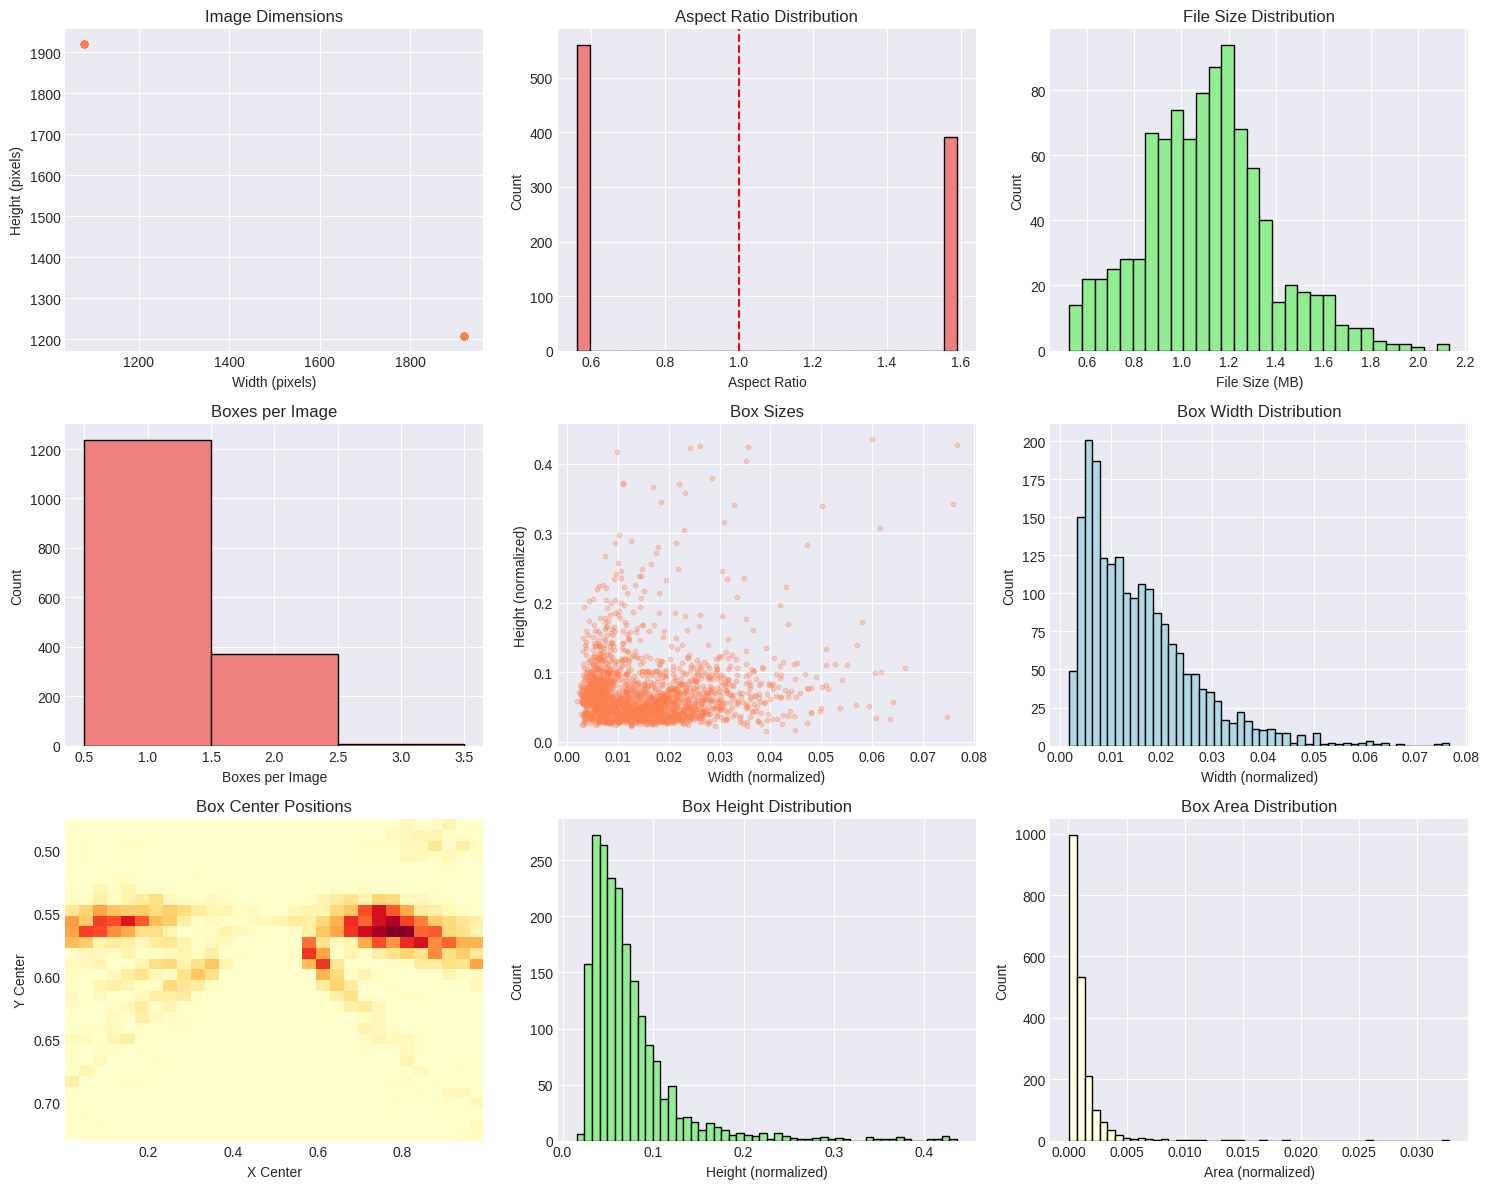

In [9]:
def create_visualizations(image_props, annotation_data, output_dir):
    """Create and save visualization plots."""
    if image_props is None or annotation_data is None:
        print("Not enough data for visualizations")
        return
    
    df_boxes = annotation_data['df_boxes']
    boxes_per_image = annotation_data['boxes_per_image']
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # 1. Image dimensions scatter
    ax = axes[0, 0]
    ax.scatter(image_props['dimensions'][:, 0], image_props['dimensions'][:, 1], 
               alpha=0.5, c='coral', s=20)
    ax.set_xlabel('Width (pixels)')
    ax.set_ylabel('Height (pixels)')
    ax.set_title('Image Dimensions')
    
    # 2. Aspect ratio distribution
    ax = axes[0, 1]
    ax.hist(image_props['aspect_ratios'], bins=30, color='lightcoral', edgecolor='black')
    ax.axvline(1.0, color='red', linestyle='--', label='1:1')
    ax.set_xlabel('Aspect Ratio')
    ax.set_ylabel('Count')
    ax.set_title('Aspect Ratio Distribution')
    
    # 3. File size distribution
    ax = axes[0, 2]
    ax.hist(image_props['file_sizes'], bins=30, color='lightgreen', edgecolor='black')
    ax.set_xlabel('File Size (MB)')
    ax.set_ylabel('Count')
    ax.set_title('File Size Distribution')
    
    # 4. Boxes per image
    ax = axes[1, 0]
    ax.hist(boxes_per_image, bins=range(1, max(boxes_per_image)+2), 
            color='lightcoral', edgecolor='black', align='left')
    ax.set_xlabel('Boxes per Image')
    ax.set_ylabel('Count')
    ax.set_title('Boxes per Image')
    
    # 5. Box sizes scatter
    ax = axes[1, 1]
    ax.scatter(df_boxes['width'], df_boxes['height'], alpha=0.3, c='coral', s=10)
    ax.set_xlabel('Width (normalized)')
    ax.set_ylabel('Height (normalized)')
    ax.set_title('Box Sizes')
    
    # 6. Box width distribution
    ax = axes[1, 2]
    ax.hist(df_boxes['width'], bins=50, color='lightblue', edgecolor='black')
    ax.set_xlabel('Width (normalized)')
    ax.set_ylabel('Count')
    ax.set_title('Box Width Distribution')
    
    # 7. Box center positions heatmap
    ax = axes[2, 0]
    ax.hist2d(df_boxes['x_center'], df_boxes['y_center'], bins=30, cmap='YlOrRd')
    ax.set_xlabel('X Center')
    ax.set_ylabel('Y Center')
    ax.set_title('Box Center Positions')
    ax.invert_yaxis()  # Image coordinates
    
    # 8. Box height distribution
    ax = axes[2, 1]
    ax.hist(df_boxes['height'], bins=50, color='lightgreen', edgecolor='black')
    ax.set_xlabel('Height (normalized)')
    ax.set_ylabel('Count')
    ax.set_title('Box Height Distribution')
    
    # 9. Box area distribution
    ax = axes[2, 2]
    ax.hist(df_boxes['area'], bins=50, color='lightyellow', edgecolor='black')
    ax.set_xlabel('Area (normalized)')
    ax.set_ylabel('Count')
    ax.set_title('Box Area Distribution')
    
    plt.tight_layout()
    
    # Save figure
    output_path = output_dir / 'eda_analysis.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved analysis figure to: {output_path}")
    plt.show()

create_visualizations(image_props, annotation_data, OUTPUT_DIR)

## 8. Sample Images with Annotations


Sample Images with Annotations

✓ Saved sample images to: eda_outputs/sample_images.png


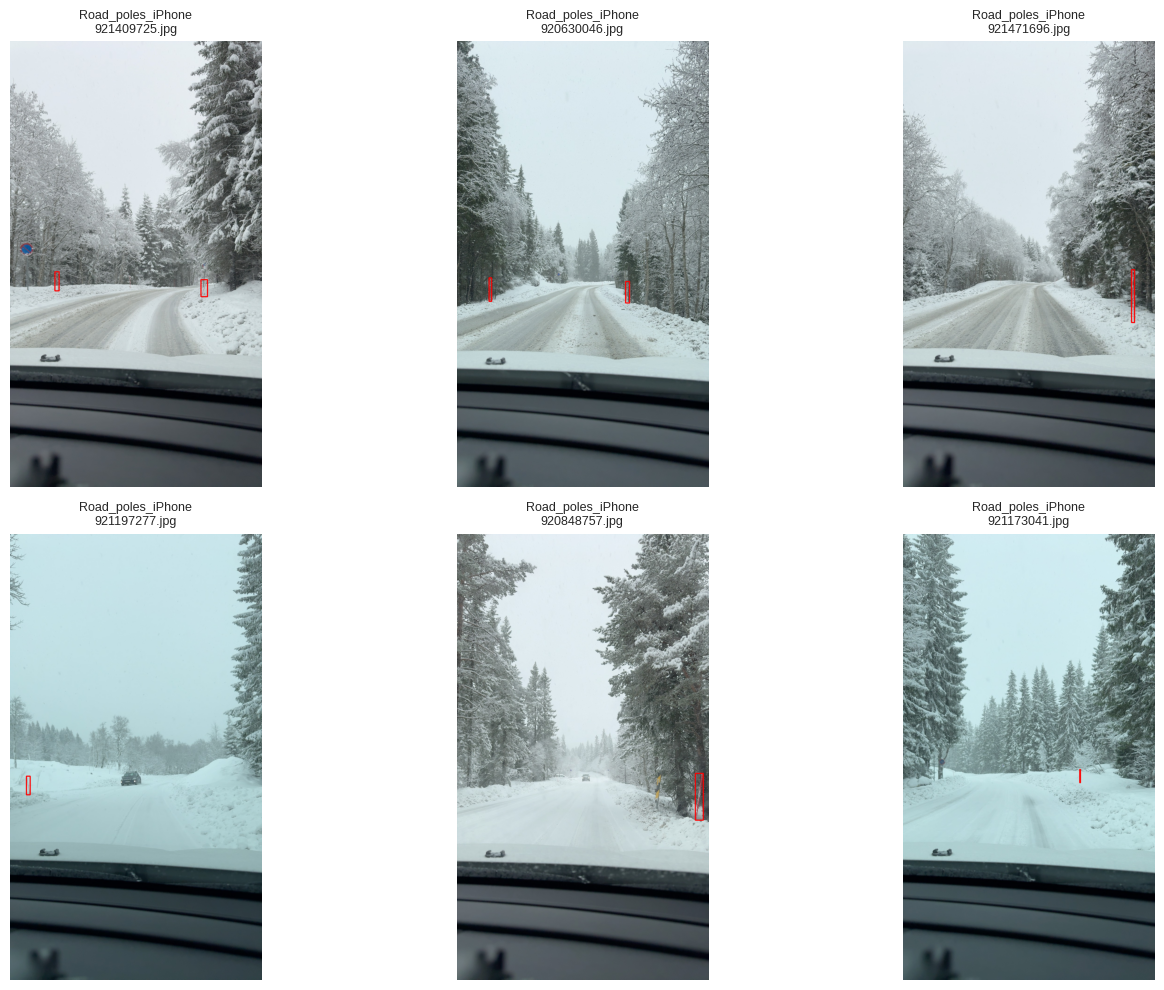

In [10]:
def show_sample_images(stats_dict, num_samples=6):
    """Display sample images with bounding boxes."""
    print(f"\n{'='*80}")
    print("Sample Images with Annotations")
    print(f"{'='*80}")
    
    samples = []
    
    for dataset_name, stats in stats_dict.items():
        for split_name, split_data in stats['splits'].items():
            if 'test' in split_name.lower():
                continue
            
            labels_path = split_data['labels_path']
            images_path = split_data['images_path']
            
            if not labels_path or not labels_path.exists():
                continue
            
            # Find images with labels
            for img_file in split_data['image_files'][:50]:  # Check first 50
                txt_file = labels_path / (img_file.stem + '.txt')
                if txt_file.exists():
                    lines = read_yolo_label(txt_file)
                    if lines:
                        samples.append({
                            'image': img_file,
                            'label': txt_file,
                            'dataset': dataset_name,
                            'split': split_name
                        })
                        if len(samples) >= num_samples * 2:
                            break
    
    if not samples:
        print("No samples found!")
        return
    
    # Select random samples
    np.random.shuffle(samples)
    samples = samples[:num_samples]
    
    # Plot samples
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = axes.flatten() if rows > 1 else [axes] if rows == 1 and cols == 1 else axes
    
    for idx, sample in enumerate(samples):
        ax = axes[idx]
        
        # Load image
        img = cv2.imread(str(sample['image']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Read labels
        lines = read_yolo_label(sample['label'])
        
        # Draw boxes
        for line in lines:
            box = parse_yolo_line(line)
            if box:
                # Convert normalized to pixel coordinates
                x_center = box['x_center'] * w
                y_center = box['y_center'] * h
                box_w = box['width'] * w
                box_h = box['height'] * h
                
                x1 = int(x_center - box_w/2)
                y1 = int(y_center - box_h/2)
                x2 = int(x_center + box_w/2)
                y2 = int(y_center + box_h/2)
                
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
        
        ax.imshow(img)
        ax.set_title(f"{sample['dataset']}\n{sample['image'].name}", fontsize=9)
        ax.axis('off')
    
    # Hide empty subplots
    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    output_path = OUTPUT_DIR / 'sample_images.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved sample images to: {output_path}")
    plt.show()

show_sample_images(all_stats, num_samples=6)

## 9. Summary

In [11]:
def print_summary(all_stats, annotation_data, output_dir):
    """Print and save summary statistics."""
    print(f"\n{'='*80}")
    print("DATASET SUMMARY")
    print(f"{'='*80}")
    
    summary = {
        'datasets': {},
        'total_images': 0,
        'total_labels': 0,
        'total_boxes': 0,
        'label_format': 'txt'
    }
    
    for dataset_name, stats in all_stats.items():
        print(f"\n{dataset_name}:")
        print(f"  Total images: {stats['total_images']}")
        print(f"  Total labels: {stats['total_labels']}")
        
        summary['datasets'][dataset_name] = {
            'total_images': stats['total_images'],
            'total_labels': stats['total_labels'],
            'splits': {}
        }
        
        for split_name, split_data in stats['splits'].items():
            print(f"  {split_name}: {split_data['images']} images, {split_data['labels']} labels")
            summary['datasets'][dataset_name]['splits'][split_name] = {
                'images': split_data['images'],
                'labels': split_data['labels']
            }
        
        summary['total_images'] += stats['total_images']
        summary['total_labels'] += stats['total_labels']
    
    if annotation_data:
        summary['total_boxes'] = len(annotation_data['df_boxes'])
        summary['avg_boxes_per_image'] = float(annotation_data['boxes_per_image'].mean())
    
    print(f"\n{'='*80}")
    print(f"GRAND TOTAL:")
    print(f"  Images: {summary['total_images']}")
    print(f"  Labels: {summary['total_labels']}")
    print(f"  Bounding boxes: {summary['total_boxes']}")
    print(f"{'='*80}")
    
    # Save summary to JSON
    summary_path = output_dir / 'eda_summary.json'
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"\n✓ Summary saved to: {summary_path}")
    
    return summary

summary = print_summary(all_stats, annotation_data, OUTPUT_DIR)


DATASET SUMMARY

Road_poles_iPhone:
  Total images: 1341
  Total labels: 1203
  Train: 942 images, 942 labels
  Validation: 261 images, 261 labels
  Test: 138 images, 0 labels

roadpoles_v1:
  Total images: 460
  Total labels: 414
  train: 322 images, 322 labels
  valid: 92 images, 92 labels
  test: 46 images, 0 labels

GRAND TOTAL:
  Images: 1801
  Labels: 1617
  Bounding boxes: 2004

✓ Summary saved to: eda_outputs/eda_summary.json


## 10. Key Findings

In [12]:
print("""
================================================================================
KEY FINDINGS FOR TRAINING
================================================================================

1. LABEL FORMAT:
   - Labels are in standard YOLO .txt format ✓
   - Dataset is read-only, use symlinks or copy for training

2. OBJECT CHARACTERISTICS:
   - Snow poles are SMALL objects (width ~1-4%, height ~5-20% of image)
   - Tall and thin aspect ratio (width << height)
   - Usually 1-2 poles per image, max 3
   - Concentrated on LEFT and RIGHT edges of road

3. DATASET RECOMMENDATIONS:
   - roadpoles_v1: Better label coverage, recommended for initial training
   - Road_poles_iPhone: Larger dataset, good for augmentation
   - Combined: Best for final model

4. MODEL RECOMMENDATIONS:
   - Use YOLOv8n/v9t/v11n (small models for edge deployment)
   - Enable mosaic augmentation for small object detection
   - Consider input resolution 640 for small objects
   - No rotation augmentation (poles are vertical)

5. AUGMENTATION STRATEGY:
   - High brightness variation (snow, fog, darkness)
   - Horizontal flip OK
   - NO vertical flip (poles point up)
   - NO rotation (poles must stay vertical)
   - Scale variation (poles at different distances)

================================================================================
""")


KEY FINDINGS FOR TRAINING

1. LABEL FORMAT:
   - Labels are in standard YOLO .txt format ✓
   - Dataset is read-only, use symlinks or copy for training

2. OBJECT CHARACTERISTICS:
   - Snow poles are SMALL objects (width ~1-4%, height ~5-20% of image)
   - Tall and thin aspect ratio (width << height)
   - Usually 1-2 poles per image, max 3
   - Concentrated on LEFT and RIGHT edges of road

3. DATASET RECOMMENDATIONS:
   - roadpoles_v1: Better label coverage, recommended for initial training
   - Road_poles_iPhone: Larger dataset, good for augmentation
   - Combined: Best for final model

4. MODEL RECOMMENDATIONS:
   - Use YOLOv8n/v9t/v11n (small models for edge deployment)
   - Enable mosaic augmentation for small object detection
   - Consider input resolution 640 for small objects
   - No rotation augmentation (poles are vertical)

5. AUGMENTATION STRATEGY:
   - High brightness variation (snow, fog, darkness)
   - Horizontal flip OK
   - NO vertical flip (poles point up)
   - NO rot

In [13]:
print(f"\n✅ EDA Complete!")
print(f"\nOutput files saved to: {OUTPUT_DIR}/")
print(f"  - eda_analysis.png")
print(f"  - sample_images.png")
print(f"  - eda_summary.json")
print(f"\nNext: Run Training.ipynb to train models.")


✅ EDA Complete!

Output files saved to: eda_outputs/
  - eda_analysis.png
  - sample_images.png
  - eda_summary.json

Next: Run Training.ipynb to train models.
